Get only data up until 2025

In [44]:
import pandas as pd
import os
import sys

# Add the parent directory to the Python path to import from data.export
sys.path.append(os.path.abspath(".."))

df_2025_class = df_2025 = pd.read_csv("export/classification_data_2025.csv")

# duplicate study_id 4523 from merging 
df_2025_class = df_2025_class[df_2025_class['study_id'] != 4523]

len(df_2025_class['study_id'].unique()) 

3946

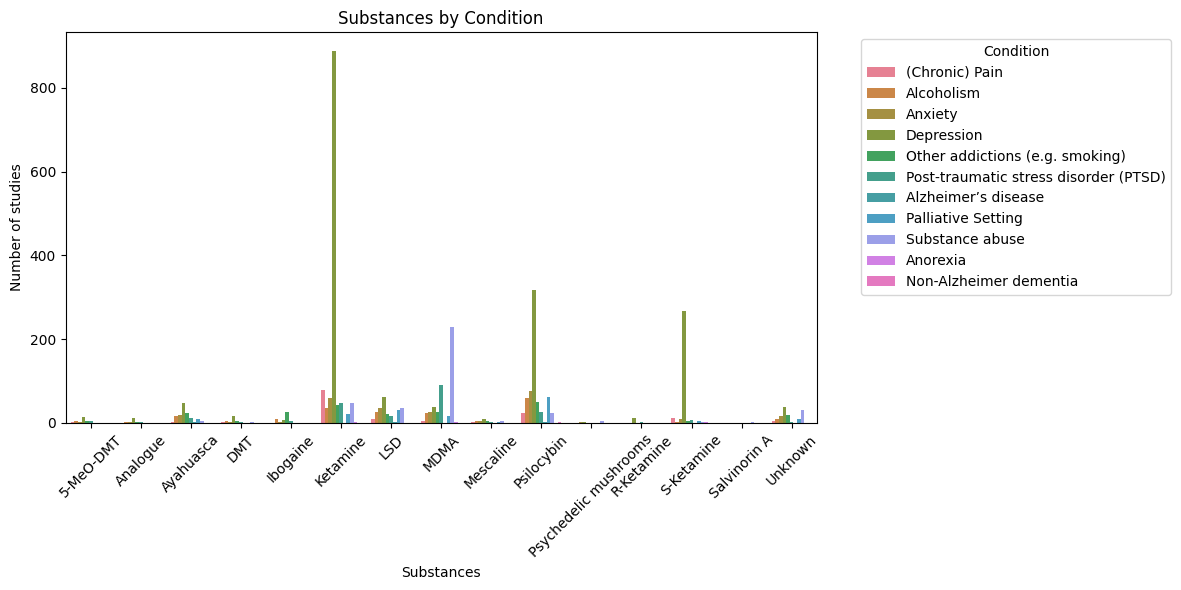

,x,group,n_studies
0,5-MeO-DMT,(Chronic) Pain,1
1,5-MeO-DMT,Alcoholism,5
2,5-MeO-DMT,Anxiety,3
3,5-MeO-DMT,Depression,15
4,5-MeO-DMT,Other addictions (e.g. smoking),4


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_task_grouped_bar(df: pd.DataFrame, x_task: str, group_task: str, exclude_labels: dict = None, figsize=(12, 6), title: str | None = None) -> pd.DataFrame:
    """
    Create a grouped bar plot from a classification DataFrame.

    Parameters:
    - df: DataFrame containing columns `study_id`, `task`, `label`.
    - x_task: task name to use for the x-axis categories (e.g., 'Substances').
    - group_task: task name to use for grouping/hue (e.g., 'Condition').
    - exclude_labels: optional dict mapping task -> list of labels to exclude.
    - figsize: figure size tuple.
    - title: optional title string.

    Returns:
    - counts DataFrame with columns [x, group, n_studies].
    """
    data = df.copy()

    # Apply exclusions if provided
    if exclude_labels:
        for task_name, labels in exclude_labels.items():
            data = data[~((data["task"] == task_name) & (data["label"].isin(labels)))]

    # Select rows for each task and rename label columns for merge
    left = data[data["task"] == x_task][["study_id", "label"]].rename(columns={"label": "x"})
    right = data[data["task"] == group_task][["study_id", "label"]].rename(columns={"label": "group"})

    # Merge on study_id and count occurrences
    merged = pd.merge(left, right, on="study_id")
    counts = merged.groupby(["x", "group"]).size().reset_index(name="n_studies")

    # Plot
    plt.figure(figsize=figsize)
    sns.barplot(data=counts, x="x", y="n_studies", hue="group")
    plt.title(title or f"{x_task} by {group_task}")
    plt.xlabel(x_task)
    plt.ylabel("Number of studies")
    plt.xticks(rotation=45)
    plt.legend(title=group_task, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return counts


# Example usage (uncomment to run):
counts = plot_task_grouped_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy"]
    }
)
counts.head()

In [46]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_task_stacked_bar(
    df: pd.DataFrame,
    x_task: str,
    group_task: str,
    exclude_labels: dict | None = None,
    merge_labels: dict | None = None,
    value_name: str = "n_studies",
    figsize=(12, 12),
):
    """
    Create a stacked bar plot where each x-category (e.g. substance) is stacked by groups (e.g. conditions).

    Parameters:
    - df: DataFrame with columns `study_id`, `task`, `label` (or additional group column).
    - x_task: task name to use for x-axis categories (rows where `task==x_task` and `label` becomes x).
    - group_task: task name to use for stacking (rows where `task==group_task` and `label` becomes group),
                  or an existing column name in `df` to use directly as group.
    - exclude_labels: optional dict mapping task -> list of labels to exclude before plotting.
    - value_name: name for the aggregated count column.
    - figsize: figure size.

    Returns the counts DataFrame used for plotting.
    """
    data = df.copy()

    # Apply exclusions (task -> list[label])
    if exclude_labels:
        for task_name, labels in exclude_labels.items():
            data = data[~((data["task"] == task_name) & (data["label"].isin(labels)))]

    if merge_labels:
        for task_name, mapping in merge_labels.items():
            for new_label, old_labels in mapping.items():
                mask = (data["task"] == task_name) & (data["label"].isin(old_labels))
                data.loc[mask, "label"] = new_label

    total_nr_studies_per_x = {}
    task_filtered = data[data['task'] == x_task]

    for label in task_filtered['label'].unique():
        # filter according to label
        df_filtered = task_filtered[task_filtered['label'] == label]
        total_nr_studies_per_x[label] = len(df_filtered['study_id'].unique())
    

    # Build left (x) dataframe from x_task
    left = data[data["task"] == x_task][["study_id", "label"]].rename(columns={"label": "x"})

    # Build right (group) dataframe either from task rows or from an existing column
    if group_task in data["task"].unique():
        right = data[data["task"] == group_task][["study_id", "label"]].rename(columns={"label": "group"})
    elif group_task in data.columns:
        right = data[["study_id", group_task]].rename(columns={group_task: "group"})
    else:
        raise ValueError(f"group_task '{group_task}' not found as a task or column in the dataframe")

    # Merge on study_id and count occurrences
    merged = pd.merge(left, right, on="study_id")
    counts = merged.groupby(["x", "group"]).size().reset_index(name=value_name)

    # Pivot for stacked plotting
    pivot = counts.pivot_table(index="x", columns="group", values=value_name, fill_value=0)

    # order by total frequency
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # Color palette
    groups = pivot.columns.tolist()
    colors = plt.cm.get_cmap("tab20", len(groups))
    color_map = {g: colors(i) for i, g in enumerate(groups)}

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    result_rows = []

    for i, x_val in enumerate(pivot.index):
        row = pivot.loc[x_val]
        sorted_row = row.sort_values(ascending=False)

        bottom = 0
        total = total_nr_studies_per_x[x_val]

        for grp, val in sorted_row.items():
            if val == 0:
                continue

            pct = (val / total) * 100
            result_rows.append({
                "x": x_val,
                "group": grp,
                "count": int(val),
                "total": int(total),
                "percentage": pct,
            })

            ax.bar(
                x_val,
                val,
                bottom=bottom,
                color=color_map[grp],
                label=grp if i == 0 else "",
            )

            ax.text(
                x_val,
                bottom + val / 2,
                f"{int(val)}\n({pct:.1f}%)",
                ha="center",
                va="center",
                fontsize=7,
            )

            bottom += val

        ax.text(
            x_val,
            bottom + bottom * 0.02, 
            f"n={int(total)}",
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
        )

    # Legend cleanup
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title=group_task, bbox_to_anchor=(1.05, 1), loc="upper left")

    # Formatting
    ax.set_title(f"{group_task} across {x_task}")
    ax.set_xlabel(x_task)
    ax.set_ylabel("Count")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(result_rows)



/tmp/ipykernel_1194/464877781.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


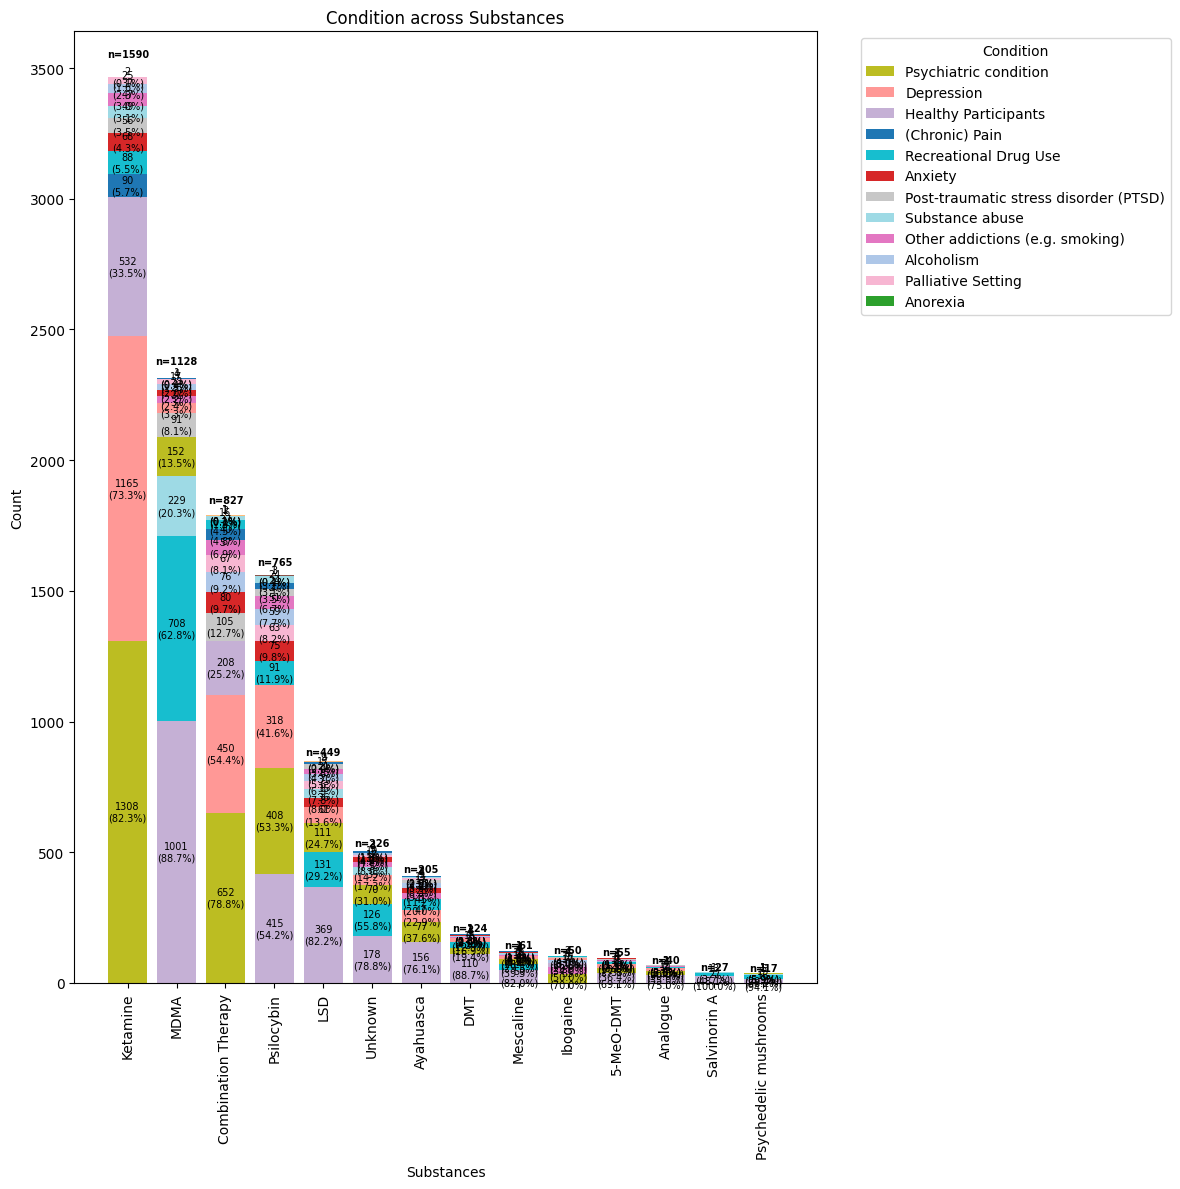

In [47]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    # exclude_labels={
    #     "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
    #     "Substances": ["Combination Therapy", 'Ketamine']
    # }
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

/tmp/ipykernel_1194/464877781.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


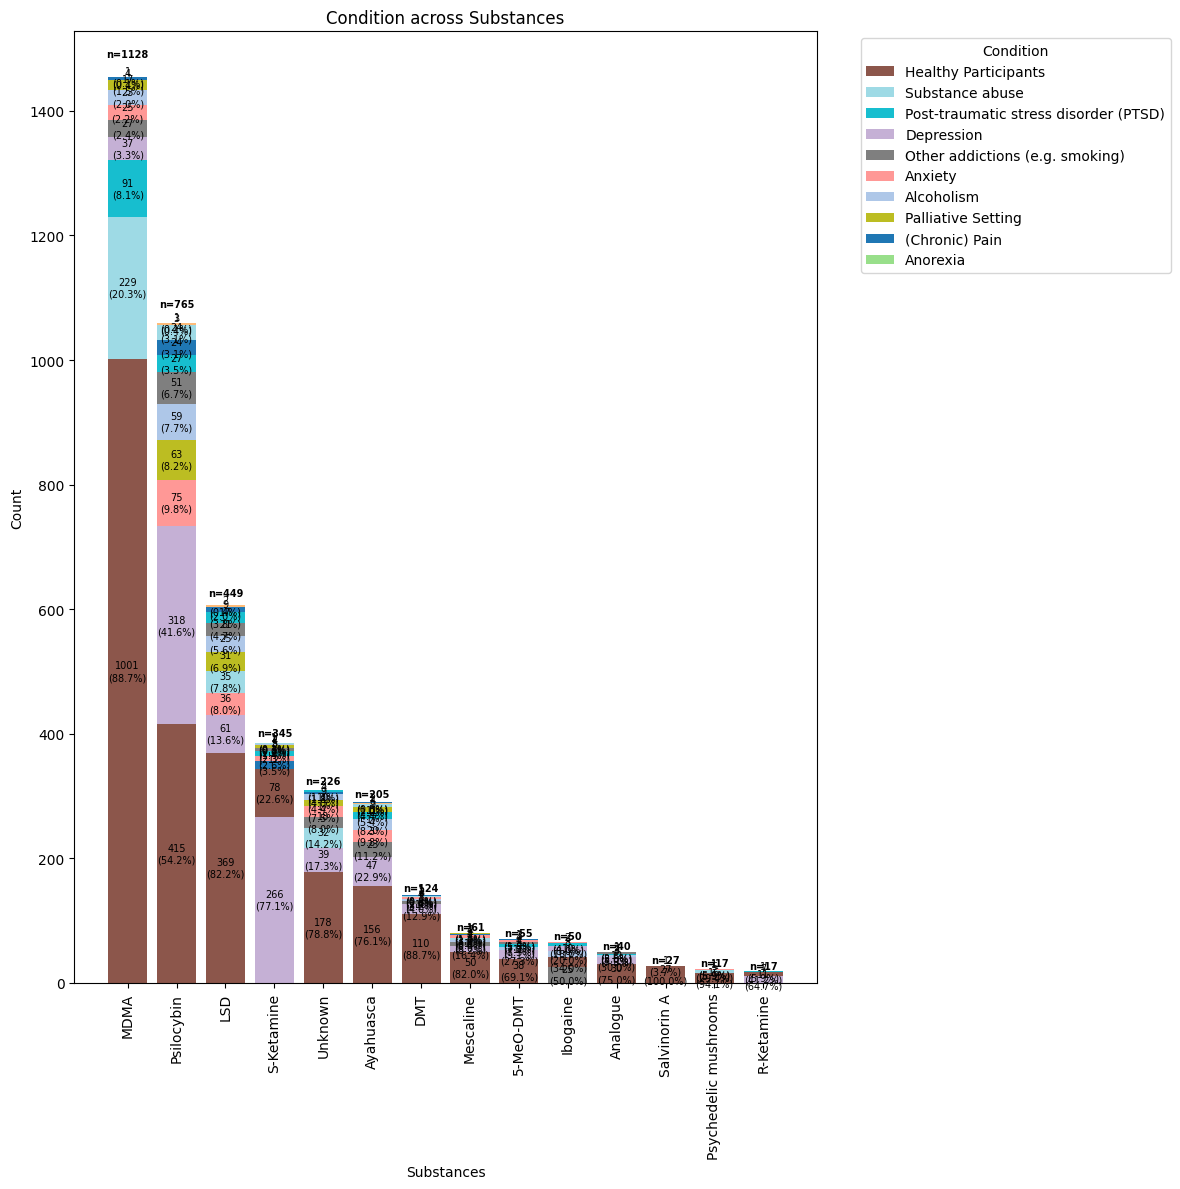

In [48]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use"],
        "Substances": ["Combination Therapy", "Ketamine", ]
    },
)

/tmp/ipykernel_1194/464877781.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


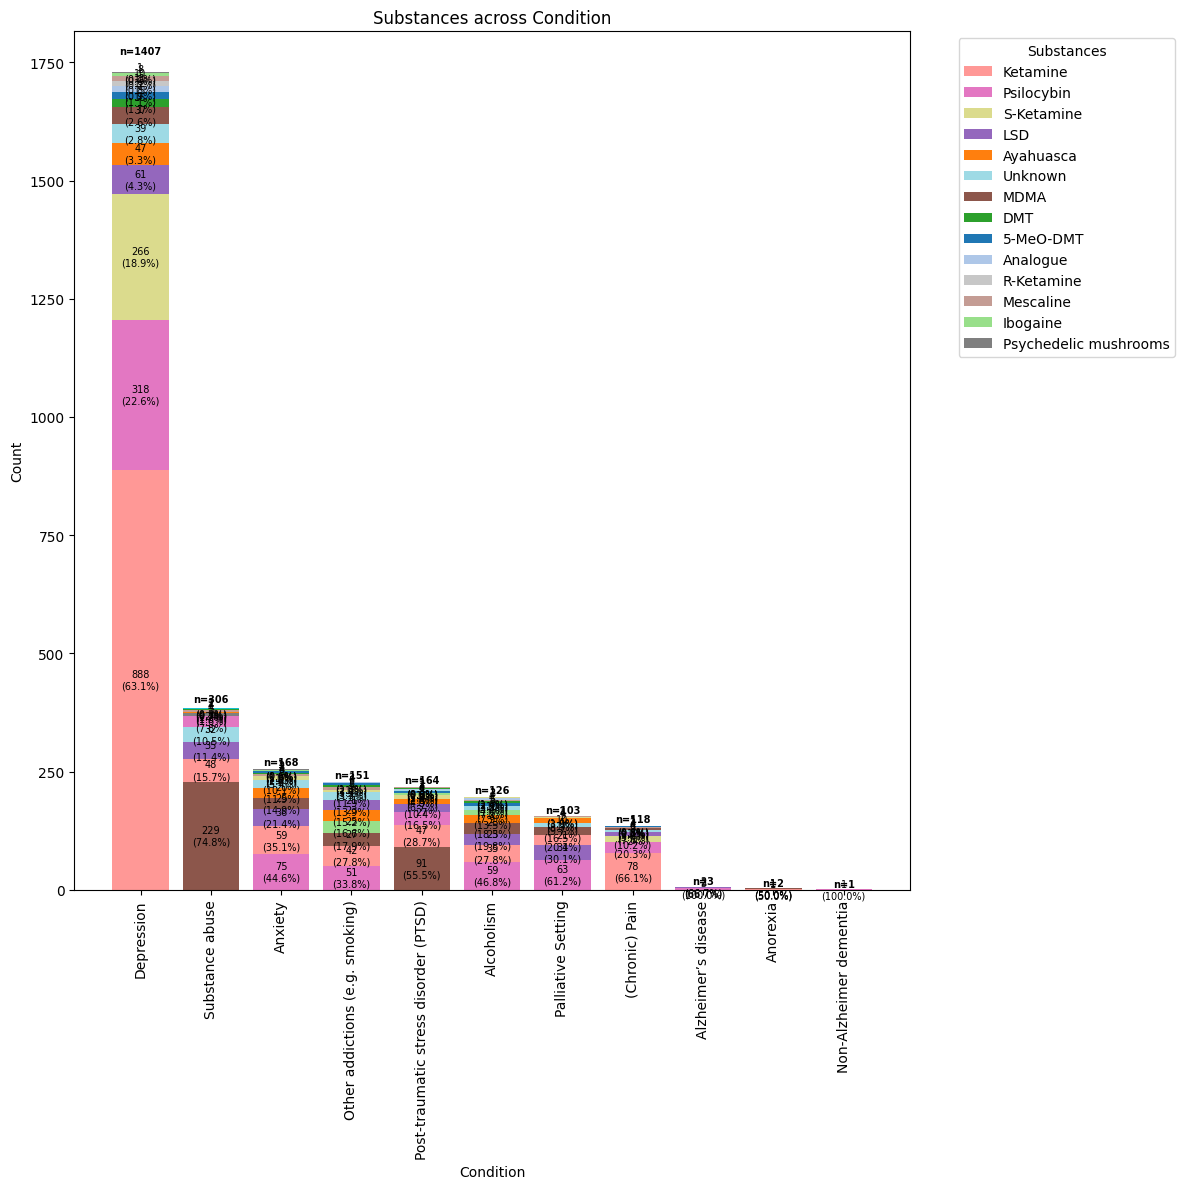

In [49]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Condition",
    group_task="Substances",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy"]
    },
)

/tmp/ipykernel_1194/464877781.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


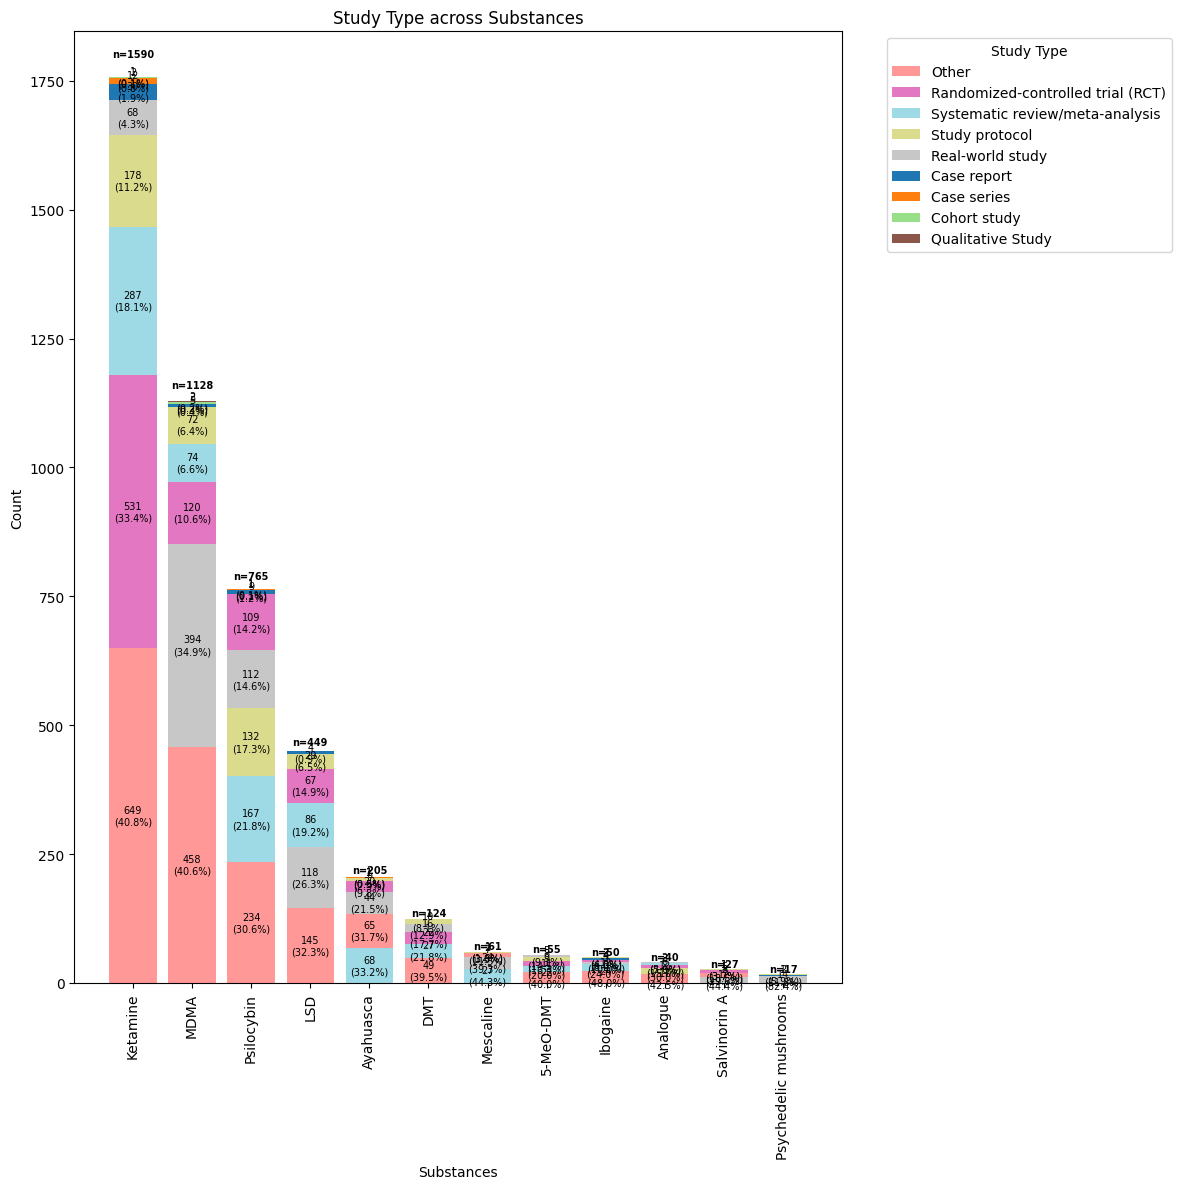

In [50]:
pct_sub_study_type = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Type",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"],
        # "Study Type": ["Other"]
    },
        merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)


In [51]:
rct_df = pct_sub_study_type[pct_sub_study_type["group"] == "Randomized-controlled trial (RCT)"]

rct_sorted = rct_df.sort_values(by="percentage", ascending=False)
print(rct_sorted)

               x                              group  count  total  percentage
1       Ketamine  Randomized-controlled trial (RCT)    531   1590   33.396226
66  Salvinorin A  Randomized-controlled trial (RCT)      5     27   18.518519
40           DMT  Randomized-controlled trial (RCT)     22    124   17.741935
50     5-MeO-DMT  Randomized-controlled trial (RCT)      9     55   16.363636
61      Analogue  Randomized-controlled trial (RCT)      6     40   15.000000
28           LSD  Randomized-controlled trial (RCT)     67    449   14.922049
21    Psilocybin  Randomized-controlled trial (RCT)    109    765   14.248366
11          MDMA  Randomized-controlled trial (RCT)    120   1128   10.638298
34     Ayahuasca  Randomized-controlled trial (RCT)     20    205    9.756098
56      Ibogaine  Randomized-controlled trial (RCT)      4     50    8.000000
47     Mescaline  Randomized-controlled trial (RCT)      1     61    1.639344


In [52]:
rct_sorted = rct_df.sort_values(by="count", ascending=False)
print(rct_sorted)


               x                              group  count  total  percentage
1       Ketamine  Randomized-controlled trial (RCT)    531   1590   33.396226
11          MDMA  Randomized-controlled trial (RCT)    120   1128   10.638298
21    Psilocybin  Randomized-controlled trial (RCT)    109    765   14.248366
28           LSD  Randomized-controlled trial (RCT)     67    449   14.922049
40           DMT  Randomized-controlled trial (RCT)     22    124   17.741935
34     Ayahuasca  Randomized-controlled trial (RCT)     20    205    9.756098
50     5-MeO-DMT  Randomized-controlled trial (RCT)      9     55   16.363636
61      Analogue  Randomized-controlled trial (RCT)      6     40   15.000000
66  Salvinorin A  Randomized-controlled trial (RCT)      5     27   18.518519
56      Ibogaine  Randomized-controlled trial (RCT)      4     50    8.000000
47     Mescaline  Randomized-controlled trial (RCT)      1     61    1.639344


/tmp/ipykernel_1194/464877781.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


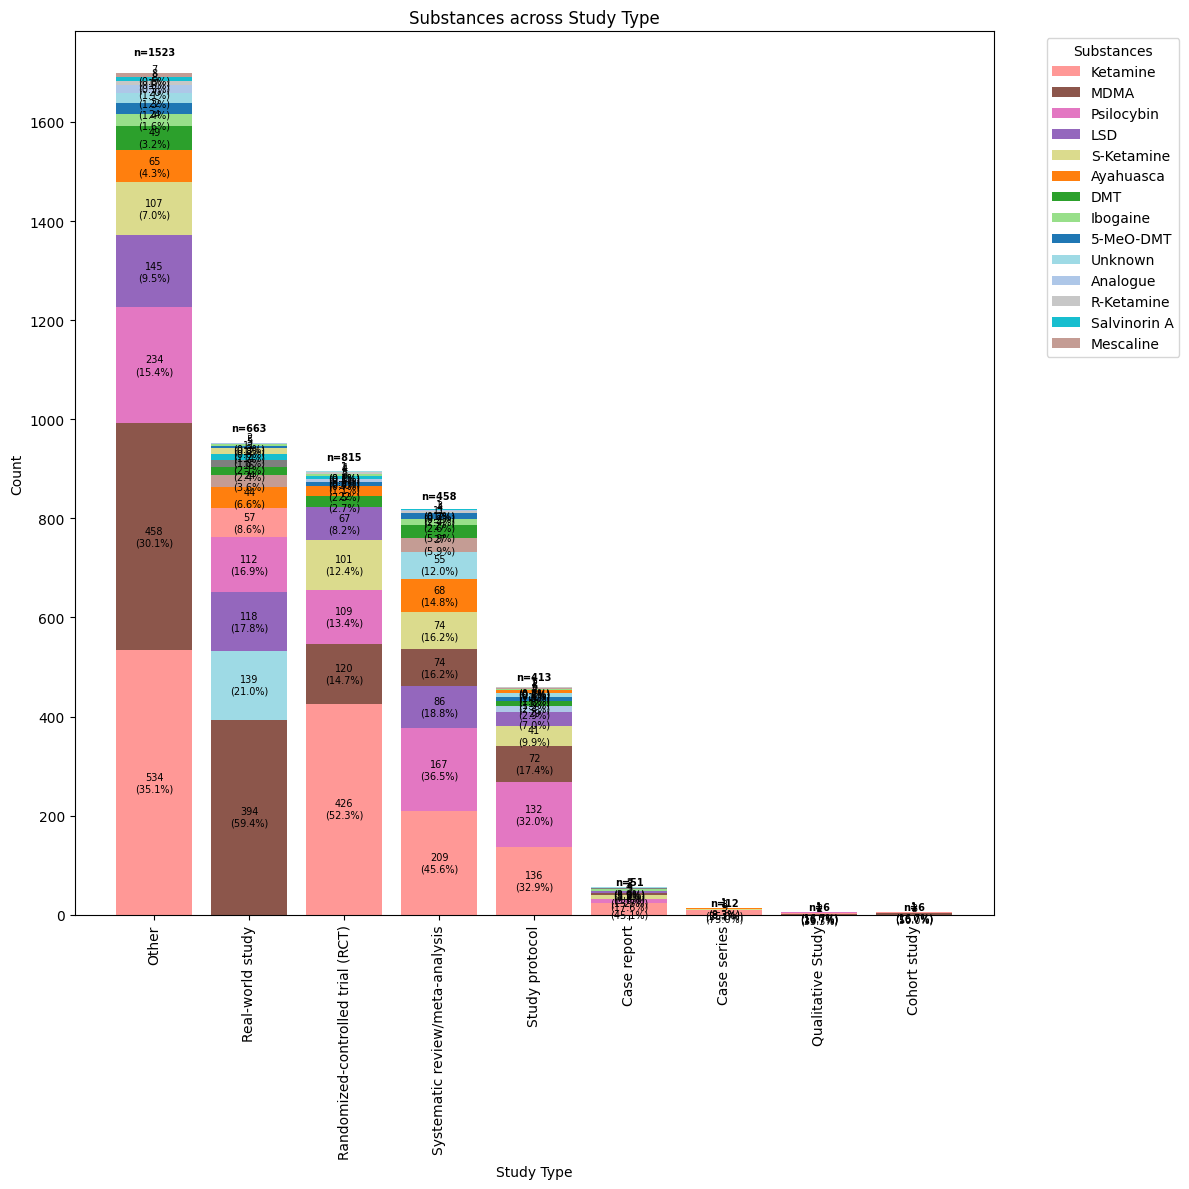

In [53]:
pct_study_type = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Type",
    group_task="Substances",
    exclude_labels={   
        "Substances": ["Combination Therapy"]
    }
)



/tmp/ipykernel_1194/464877781.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


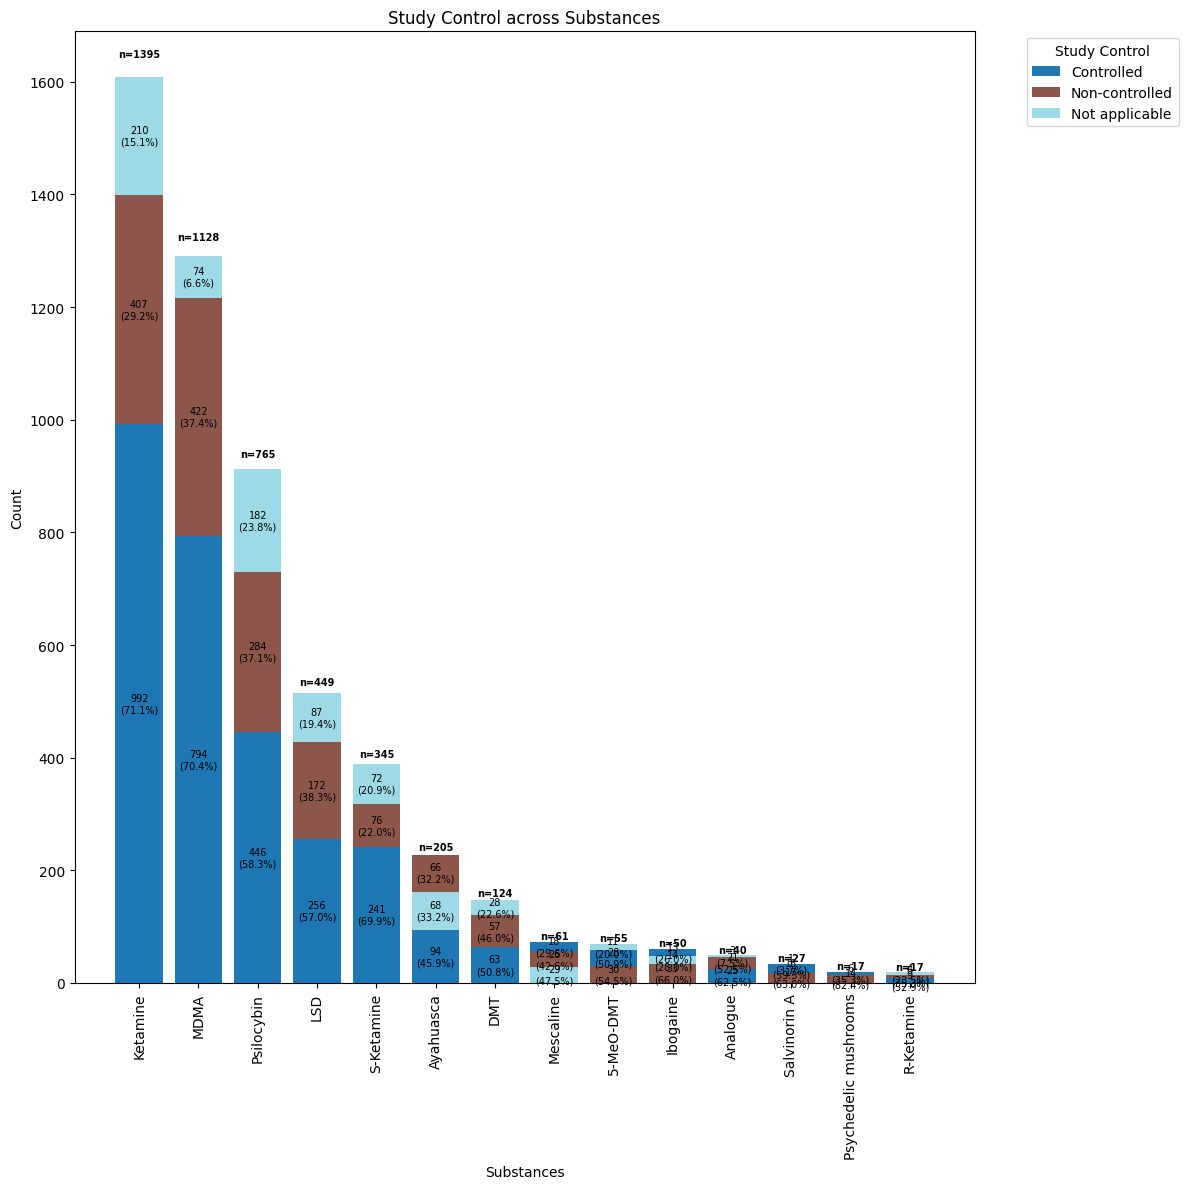

In [54]:
pct_control = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Control",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"]
    },
    merge_labels={
        'Study Control': {
            'Controlled': ['Placebo', 'Other control', 'Active control']
        }
    }
)

In [58]:
control = pct_control[pct_control["group"] == "Controlled"]
rct_sorted = control.sort_values(by="percentage", ascending=False)
print(rct_sorted)

                        x       group  count  total  percentage
0                Ketamine  Controlled    992   1395   71.111111
3                    MDMA  Controlled    794   1128   70.390071
12             S-Ketamine  Controlled    241    345   69.855072
30               Analogue  Controlled     25     40   62.500000
34           Salvinorin A  Controlled     16     27   59.259259
6              Psilocybin  Controlled    446    765   58.300654
9                     LSD  Controlled    256    449   57.015590
38             R-Ketamine  Controlled      9     17   52.941176
25              5-MeO-DMT  Controlled     28     55   50.909091
18                    DMT  Controlled     63    124   50.806452
15              Ayahuasca  Controlled     94    205   45.853659
37  Psychedelic mushrooms  Controlled      6     17   35.294118
23              Mescaline  Controlled     18     61   29.508197
29               Ibogaine  Controlled     13     50   26.000000


['Active control' 'Placebo' 'Other control' 'Non-controlled'
 'Not applicable']
{'Active control': 373, 'Placebo': 1286, 'Other control': 1034, 'Non-controlled': 1402, 'Not applicable': 475}


/tmp/ipykernel_1194/1785370960.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


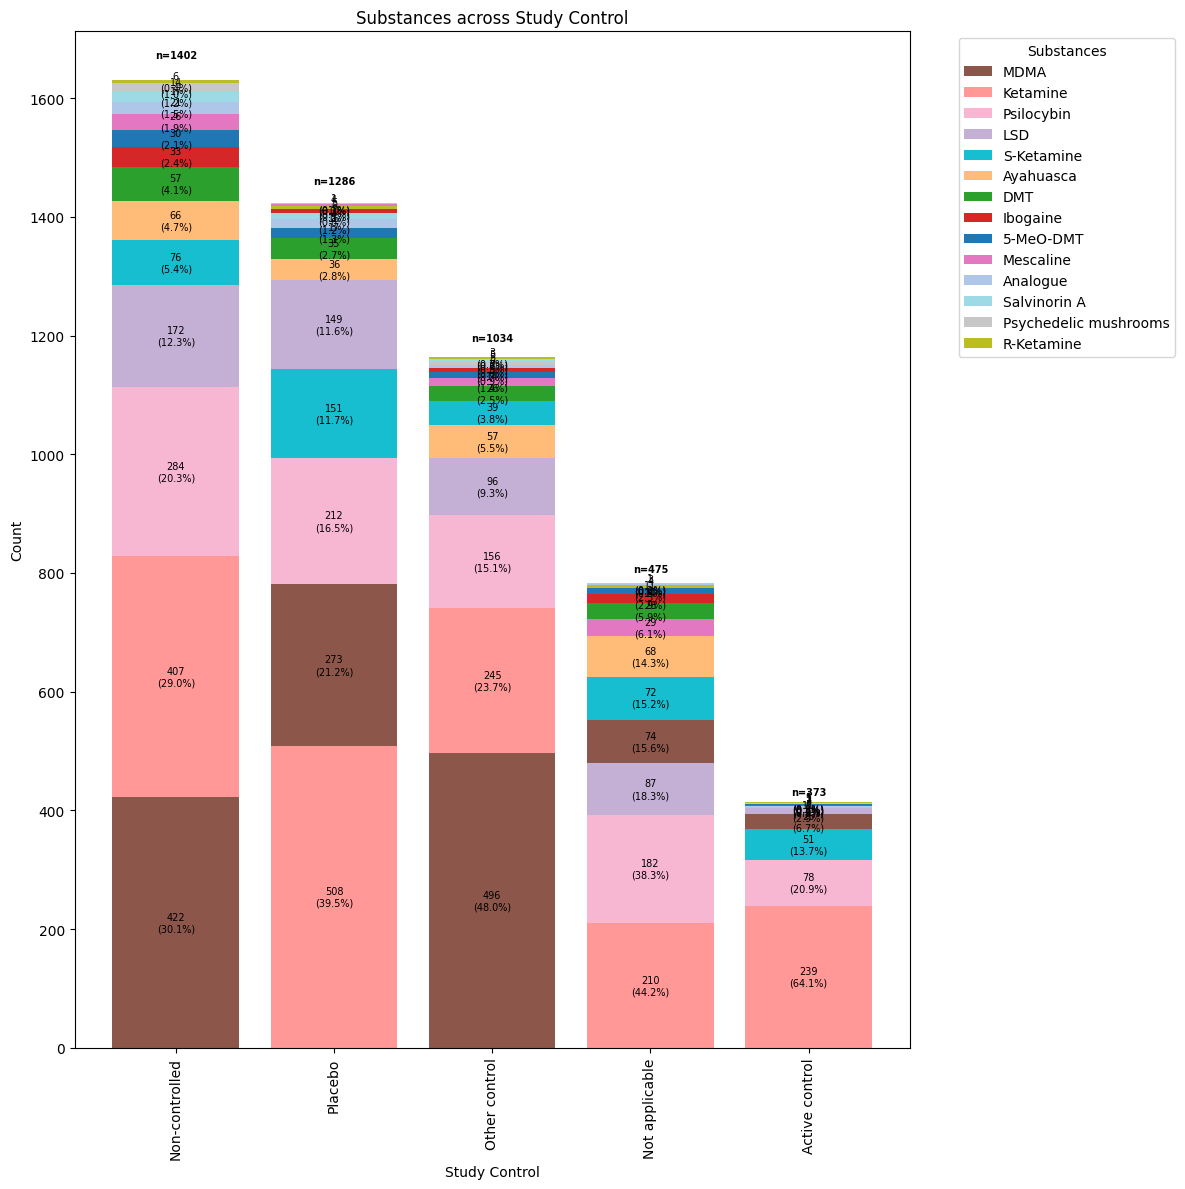

In [ ]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Control",
    group_task="Substances",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"]
    }
)

['Ketamine' 'Combination Therapy' 'S-Ketamine' 'MDMA' 'LSD' 'Psilocybin'
 'Unknown' 'Salvinorin A' 'R-Ketamine' 'Ayahuasca' 'DMT' 'Analogue'
 'Mescaline' 'Psychedelic mushrooms' 'Ibogaine' '5-MeO-DMT']
{'Ketamine': 1395, 'Combination Therapy': 827, 'S-Ketamine': 345, 'MDMA': 1128, 'LSD': 449, 'Psilocybin': 765, 'Unknown': 226, 'Salvinorin A': 27, 'R-Ketamine': 17, 'Ayahuasca': 205, 'DMT': 124, 'Analogue': 40, 'Mescaline': 61, 'Psychedelic mushrooms': 17, 'Ibogaine': 50, '5-MeO-DMT': 55}


/tmp/ipykernel_1194/1785370960.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


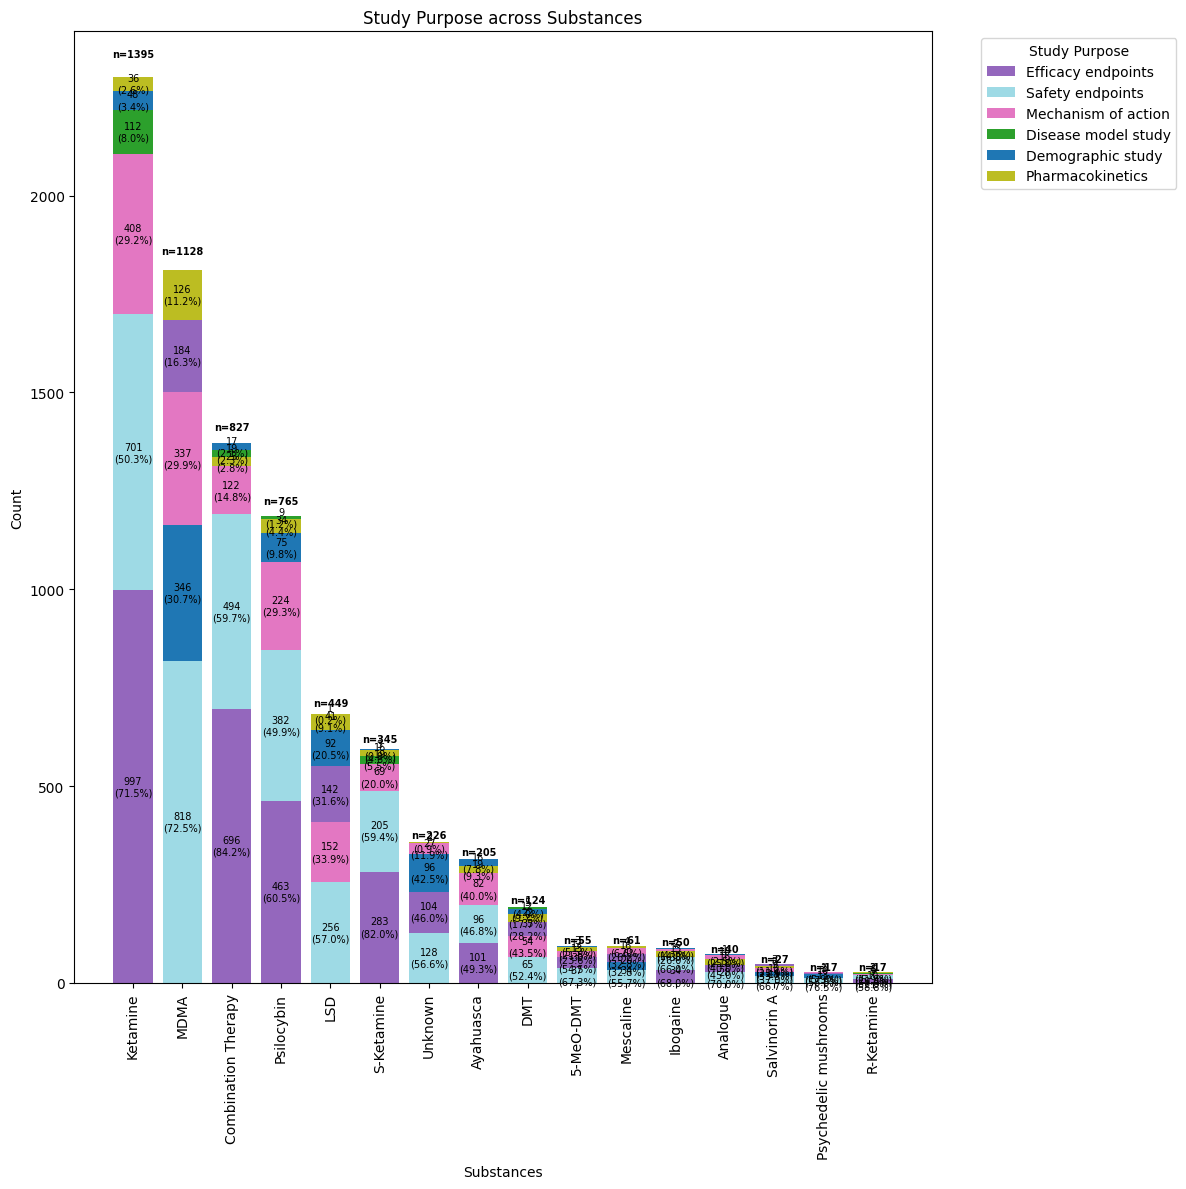

In [ ]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Purpose",
    exclude_labels={
        "Substances": ['Other', 'Unkown', 'Combination Therapy']
    }
)

['Efficacy endpoints' 'Safety endpoints' 'Demographic study'
 'Mechanism of action' 'Pharmacokinetics' 'Disease model study']
{'Efficacy endpoints': 1971, 'Safety endpoints': 2265, 'Demographic study': 493, 'Mechanism of action': 1217, 'Pharmacokinetics': 293, 'Disease model study': 129}


/tmp/ipykernel_1194/1785370960.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(groups))


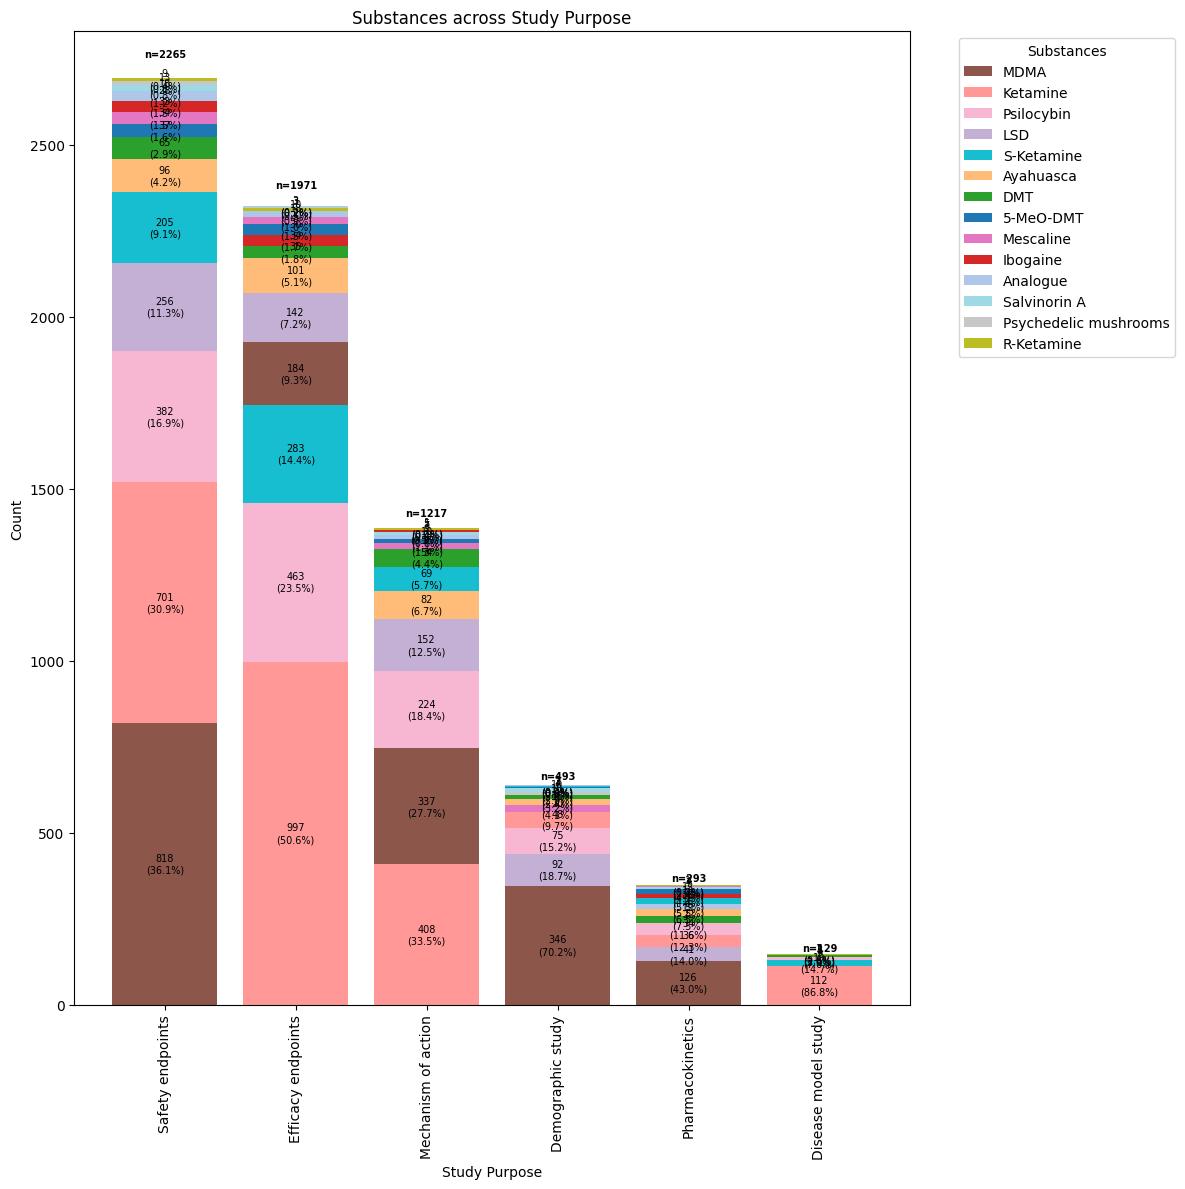

In [ ]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Purpose",
    group_task="Substances",
    exclude_labels={
        "Substances": ['Other', 'Unknown', 'Combination Therapy']
    }
)